In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pandas as pd

# # Load the proteomics TSV file
# prot_file = r'E-PROT-28-query-results.tsv'

# df_prot = pd.read_csv(prot_file, sep='\t', engine='python', on_bad_lines='skip')

# df_prot.head(10)

# load files
results = pd.read_csv('E-PROT-28-query-results.tsv', sep='\t')
metadata = pd.read_csv('E-PROT-28-experiment-design.tsv', sep='\t')

# long format
results_long = results.melt(
    id_vars=['Gene ID', 'Gene Name'], 
    var_name='Cell Line', 
    value_name='iBAQ'
)

# 3. 
meta_subset = metadata[[
    'Factor Value[cell line]', 
    'Sample Characteristic[disease]', 
    'Sample Characteristic[organism part]',
    'Sample Characteristic[disease staging]'
]].drop_duplicates()

# merge
combined_data = pd.merge(
    results_long, 
    meta_subset, 
    left_on='Cell Line', 
    right_on='Factor Value[cell line]', 
    how='left'
)

combined_data.head()


combined_data.to_csv('combined_proteomics_data.csv', index=False)

In [ ]:

df = combined_data

df['log10_iBAQ'] = df['iBAQ'].apply(lambda x: np.log10(x) if x > 0 else 0)



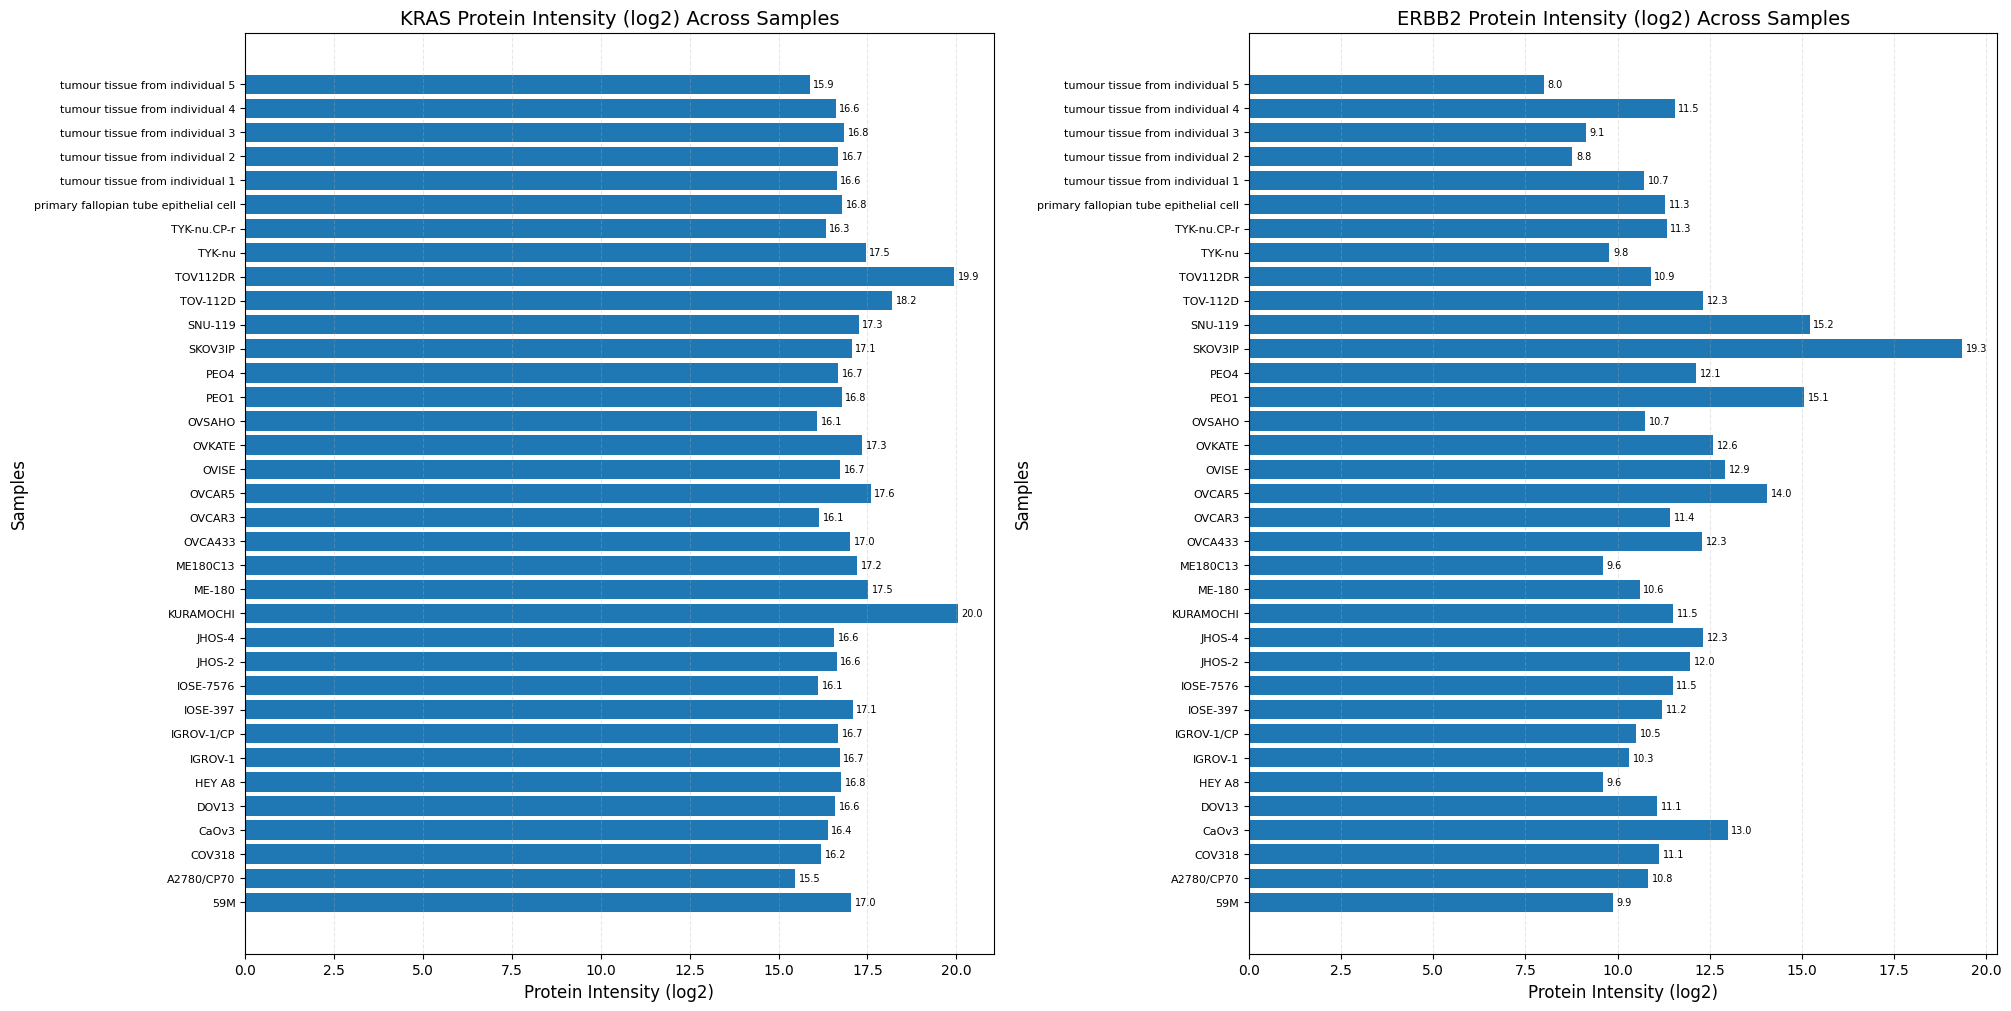

In [30]:
def get_gene_plot_data(gene_name):
    gene_data = combined_data[combined_data['Gene Name'].str.upper() == gene_name.upper()]
    # gene_data = gene_data.dropna(subset=['iBAQ']).sort_values('iBAQ', ascending=True)
    return gene_data['Cell Line'].tolist(), np.log2(gene_data['iBAQ'])

def plot_bar_graph(ax, cell_lines, log2_intensities, gene_name):
    ax.barh(range(len(cell_lines)), log2_intensities)
    ax.set_ylabel('Samples', fontsize=12)
    ax.set_xlabel('Protein Intensity (log2)', fontsize=12)
    ax.set_title(f'{gene_name} Protein Intensity (log2) Across Samples', fontsize=14)
    ax.set_yticks(range(len(cell_lines)))
    ax.set_yticklabels(cell_lines, fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    for i, v in enumerate(log2_intensities):
        ax.text(v + 0.1, i, f'{v:.1f}', ha='left', va='center', fontsize=7)

genes = ['KRAS', 'ERBB2']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), constrained_layout=True)

for ax, gene in zip(axes, genes):
    cell_lines, log2_intensities = get_gene_plot_data(gene)
    plot_bar_graph(ax, cell_lines, log2_intensities, gene)

plt.show()


c:\Users\START\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\START\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


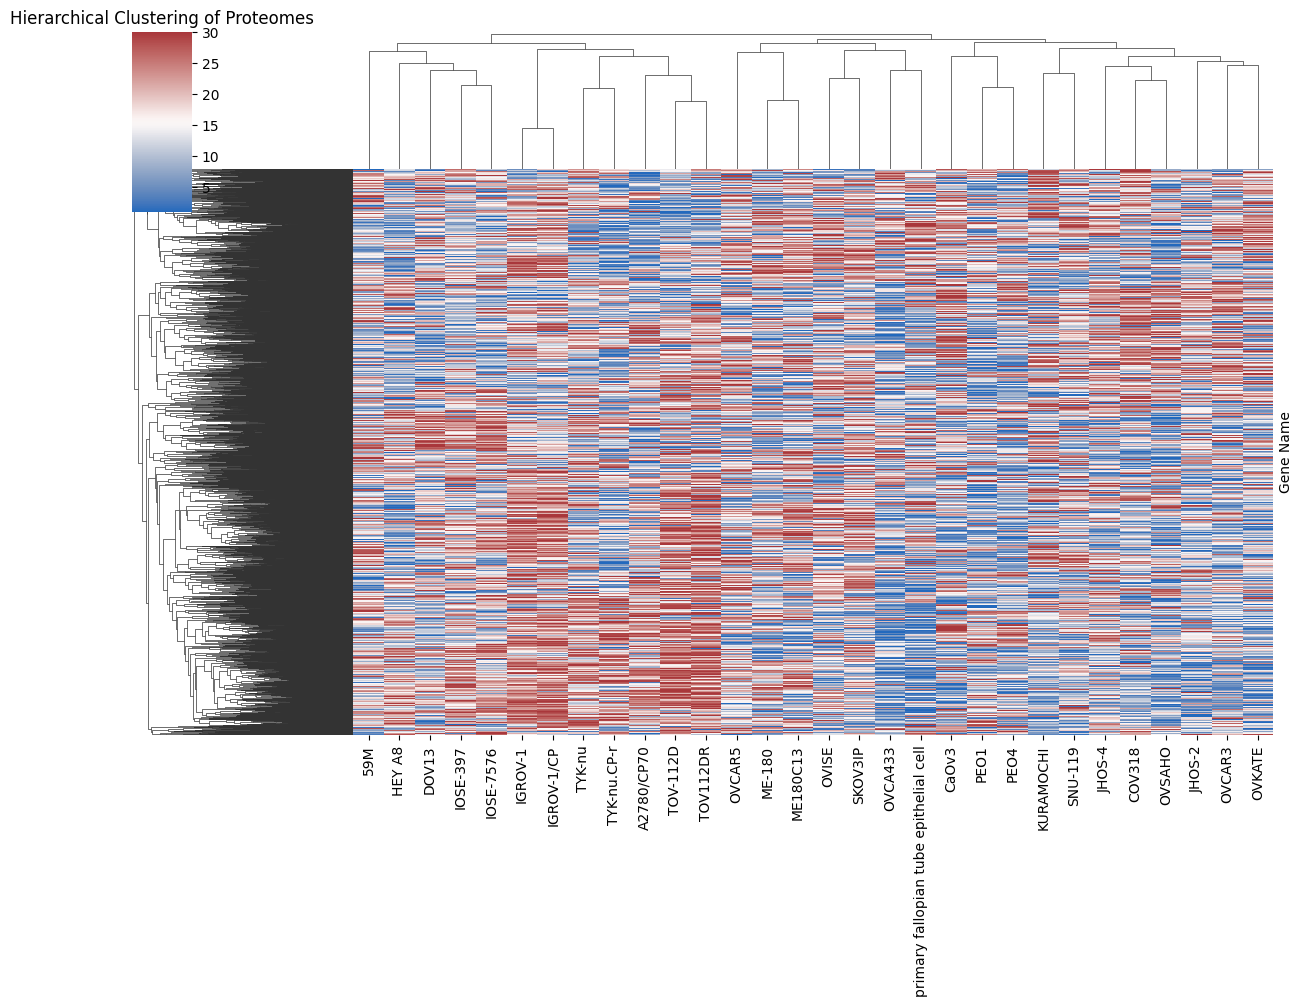

Top-level sample clusters in heatmap order:
Cluster 1 (12 samples): ['59M', 'HEY A8', 'DOV13', 'IOSE-397', 'IOSE-7576', 'IGROV-1', 'IGROV-1/CP', 'TYK-nu', 'TYK-nu.CP-r', 'A2780/CP70', 'TOV-112D', 'TOV112DR']
Cluster 2 (7 samples): ['OVCAR5', 'ME-180', 'ME180C13', 'OVISE', 'SKOV3IP', 'OVCA433', 'primary fallopian tube epithelial cell']
Cluster 3 (11 samples): ['CaOv3', 'PEO1', 'PEO4', 'KURAMOCHI', 'SNU-119', 'JHOS-4', 'COV318', 'OVSAHO', 'JHOS-2', 'OVCAR3', 'OVKATE']


In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# Load and prepare data
df = pd.read_csv('E-PROT-28-query-results.tsv', sep='\t')
cell_line_cols = df.columns[2:32]  # First 30 cell lines
data = df[cell_line_cols].set_index(df['Gene Name'])

# log transform
data_log = np.log2(data.replace(0, np.nan))

# Filter proteins with at least 50% non-missing values
data_filtered = data_log.dropna(thresh=len(data_log.columns) * 0.5)

# 3. Impute missing values based on normal distribution width 0.15, down-shift 1.8)

def impute_perseus(col):
    m, s = col.mean(), col.std()
    impute_mean = m - 1.8 * s
    impute_std = 0.15 * s
    return col.fillna(pd.Series(np.random.normal(impute_mean, impute_std, size=len(col)), index=col.index))

data_imputed = data_filtered.apply(impute_perseus, axis=0)

# z score
data_z = data_imputed.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# rank for spearman correlation
data_ranks = data_z.rank(axis=1)

# heatmap plotting
g = sns.clustermap(
    data_ranks,
    method='average',
    metric='correlation',
    cmap='vlag',
    figsize=(12, 10),
    xticklabels=True,
    yticklabels=False
)
plt.title('Hierarchical Clustering of Proteomes')
plt.show()

# Extract top-level clusters (3 clusters) for columns (samples)
sample_clusters = fcluster(g.dendrogram_col.linkage, t=3, criterion='maxclust')
sample_cluster_df = pd.DataFrame({
    'Sample': data_ranks.columns,
    'Cluster': sample_clusters
})

# Reorder samples to match the heatmap column order
col_order = g.dendrogram_col.reordered_ind
sample_cluster_df = sample_cluster_df.iloc[col_order].reset_index(drop=True)

print("Top-level sample clusters in heatmap order:")
for cluster in range(1, 4):
    samples_in_cluster = sample_cluster_df[sample_cluster_df['Cluster'] == cluster]['Sample'].tolist()
    print(f"Cluster {cluster} ({len(samples_in_cluster)} samples): {samples_in_cluster}")